In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support.ui import Select
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
import time
import csv
import pandas as pd
from datetime import datetime
import pytz 
from fake_useragent import UserAgent
import re

import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
data = pd.read_csv('final_merged_data.csv')

In [3]:
data.columns

Index(['Geographic Area Name',
       'Estimate!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Did not work',
       'Estimate!!Percent below poverty level!!Population for whom poverty status is determined!!WORK EXPERIENCE!!Population 16 years and over!!Worked full-time, year-round in the past 12 months',
       'Estimate!!Total!!Population for whom poverty status is determined!!AGE!!Under 18 years',
       'Geographic Area Name_x', 'Area_Type', 'Tract', 'Plurality Race',
       ' !!Total:!!Population of one race:!!White alone_PROPORTION',
       ' !!Total:!!Population of one race:!!Black or African American alone_PROPORTION',
       ' !!Total:!!Population of one race:!!American Indian and Alaska Native alone_PROPORTION',
       ' !!Total:!!Population of one race:!!Asian alone_PROPORTION',
       ' !!Total:!!Population of one race:!!Native Hawaiian and Other Pacific Islander alone_PROPORTION',
       ' !!Total:!!Population of one race:!!Some 

In [4]:
predictors = data[['Census population, 2020','Plurality Race','Estimate!!Total!!Population 16 years and over!!AGE!!16 to 19 years','Imprisonment rate per 100,000','Estimate!!Unemployment rate!!Population 16 years and over', ' !!Total:!!Population of one race:!!White alone_PROPORTION',' !!Total:!!Population of one race:!!Black or African American alone_PROPORTION',' !!Total:!!Population of one race:!!American Indian and Alaska Native alone_PROPORTION',' !!Total:!!Population of one race:!!Asian alone_PROPORTION',' !!Total:!!Population of one race:!!Native Hawaiian and Other Pacific Islander alone_PROPORTION',' !!Total:!!Population of one race:!!Some Other Race alone_PROPORTION', 'Area_Type', 'Estimate!!Percent below poverty level!!Population for whom poverty status is determined!!WORK EXPERIENCE!!Population 16 years and over!!Worked full-time, year-round in the past 12 months','Estimate!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Did not work', 'Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years', 'Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years!!Less than high school graduate', 'Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years!!High school graduate (includes equivalency)', "Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years!!Some college or associate's degree", "Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years!!Bachelor's degree or higher"]].copy()

In [5]:
predictors


,"Census population, 2020",Plurality Race,Estimate!!Total!!Population 16 years and over!!AGE!!16 to 19 years,"Imprisonment rate per 100,000",Estimate!!Unemployment rate!!Population 16 years and over,!!Total:!!Population of one race:!!White alone_PROPORTION,!!Total:!!Population of one race:!!Black or African American alone_PROPORTION,!!Total:!!Population of one race:!!American Indian and Alaska Native alone_PROPORTION,!!Total:!!Population of one race:!!Asian alone_PROPORTION,!!Total:!!Population of one race:!!Native Hawaiian and Other Pacific Islander alone_PROPORTION,!!Total:!!Population of one race:!!Some Other Race alone_PROPORTION,Area_Type,"Estimate!!Percent below poverty level!!Population for whom poverty status is determined!!WORK EXPERIENCE!!Population 16 years and over!!Worked full-time, year-round in the past 12 months",Estimate!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Did not work,Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years,Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years!!Less than high school graduate,Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years!!High school graduate (includes equivalency),Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years!!Some college or associate's degree,Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years!!Bachelor's degree or higher
0,"3,038",White,65,99,1.0,0.615537,0.047400,0.000658,0.177090,0.003621,0.026333,Urban,2.1,21.6,1644,24,18,141,1461
1,"2,001",White,22,50,7.9,0.710145,0.019990,0.001499,0.103448,0.001999,0.020490,Urban,1.9,52.9,1174,18,46,95,1015
2,"5,504",White,202,18,3.4,0.620094,0.101926,0.004724,0.100654,0.004906,0.034702,Urban,0.0,37.9,3193,82,87,463,2561
3,"4,112",White,99,146,2.5,0.672422,0.070282,0.002918,0.097033,0.001946,0.029669,Urban,0.5,39.6,2705,78,165,362,2100
4,"3,644",White,111,410,6.4,0.537047,0.171515,0.006586,0.084248,0.001372,0.046103,Urban,1.2,66.0,2409,30,293,294,1792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,"2,738",White,228,219,1.6,0.339664,0.011322,0.016801,0.167275,0.007670,0.254565,Urban,5.9,0.0,1370,164,247,616,343
7353,"1,653",White,35,241,0.0,0.410163,0.017544,0.008469,0.128252,0.006050,0.196007,Urban,0.0,72.0,837,10,198,195,434
7354,"1,361",White,102,293,5.0,0.396032,0.005878,0.047024,0.017634,0.001470,0.351212,Urban,0.0,93.1,877,152,177,438,110
7355,"3,600",White,162,744,9.2,0.465000,0.033333,0.021944,0.134722,0.004444,0.175833,Urban,8.5,68.3,2398,382,690,892,434


In [22]:
predictors = predictors.rename(columns={'Census population, 2020': 'population'})
predictors = predictors.rename(columns={'Estimate!!Unemployment rate!!Population 16 years and over': 'unemployment_rate'})
predictors = predictors.rename(columns={'Imprisonment rate per 100,000': 'incarceration_rate'})
predictors = predictors.rename(columns={'Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years': 'education_total'})
predictors = predictors.rename(columns={'Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years!!Less than high school graduate': 'education_less_than_highschool'})
predictors = predictors.rename(columns={'Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years!!High school graduate (includes equivalency)': 'education_highschool'})
predictors = predictors.rename(columns={"Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years!!Some college or associate's degree": 'education_some_college'})
predictors = predictors.rename(columns={"Estimate!!Total!!EDUCATIONAL ATTAINMENT!!Population 25 to 64 years!!Bachelor's degree or higher": 'education_bachelors_or_higher'})
predictors = predictors.rename(columns={"Estimate!!Total!!Population 16 years and over!!AGE!!16 to 19 years": 'total_population_16_to_19'})
predictors = predictors.rename(columns={"Plurality Race": 'plurality_race'})
predictors = predictors.rename(columns={" !!Total:!!Population of one race:!!White alone_PROPORTION": 'white_proportion'})
predictors = predictors.rename(columns={" !!Total:!!Population of one race:!!Black or African American alone_PROPORTION": 'black_proportion'})
predictors = predictors.rename(columns={" !!Total:!!Population of one race:!!American Indian and Alaska Native alone_PROPORTION": 'native_american_proportion'})
predictors = predictors.rename(columns={" !!Total:!!Population of one race:!!Asian alone_PROPORTION": 'asian_proportion'})
predictors = predictors.rename(columns={" !!Total:!!Population of one race:!!Native Hawaiian and Other Pacific Islander alone_PROPORTION": 'native_hawaiian_pac_islander_proportion'})
predictors = predictors.rename(columns={" !!Total:!!Population of one race:!!Some Other Race alone_PROPORTION": 'other'})
predictors = predictors.rename(columns={"Estimate!!Percent below poverty level!!Population for whom poverty status is determined!!WORK EXPERIENCE!!Population 16 years and over!!Worked full-time, year-round in the past 12 months": 'percent_poverty_worked'})
predictors = predictors.rename(columns={"Estimate!!Percent below poverty level!!UNRELATED INDIVIDUALS FOR WHOM POVERTY STATUS IS DETERMINED!!Did not work": 'percent_poverty_did_not_work'})

In [23]:
predictors = predictors.replace('-', pd.NA)
predictors.dropna(inplace=True)

In [24]:
# # Remove commas from the 'incarceration_rate' column
predictors['incarceration_rate'] = predictors['incarceration_rate'].str.replace(',', '')
predictors['unemployment_rate'] = predictors['unemployment_rate'].str.replace(',', '')
predictors['population'] = predictors['population'].str.replace(',', '')


# # Convert the column to appropriate type
predictors['incarceration_rate'] = predictors['incarceration_rate'].astype(float)
predictors['unemployment_rate'] = predictors['unemployment_rate'].astype(float)
predictors['population'] = predictors['population'].astype(float)
predictors['percent_poverty_worked'] = predictors['percent_poverty_worked'].astype(float)
predictors['percent_poverty_did_not_work'] = predictors['percent_poverty_did_not_work'].astype(float)


AttributeError: Can only use .str accessor with string values!

In [25]:
predictors = predictors.rename(columns={"other": 'other_race_proportion'})
predictors.dtypes

population                                 float64
plurality_race                              object
total_population_16_to_19                    int64
incarceration_rate                         float64
unemployment_rate                          float64
white_proportion                           float64
black_proportion                           float64
native_american_proportion                 float64
asian_proportion                           float64
native_hawaiian_pac_islander_proportion    float64
other_race_proportion                      float64
Area_Type                                   object
percent_poverty_worked                     float64
percent_poverty_did_not_work               float64
education_total                              int64
education_less_than_highschool               int64
education_highschool                         int64
education_some_college                       int64
education_bachelors_or_higher                int64
dtype: object

# Now we have all of our predictors! Let's check for multicollinearity

/var/folders/bp/vkhmx8nd2zxgz13drv5jw3fh0000gn/T/ipykernel_10986/3112359101.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = predictors.corr().round(2)


<Axes: >

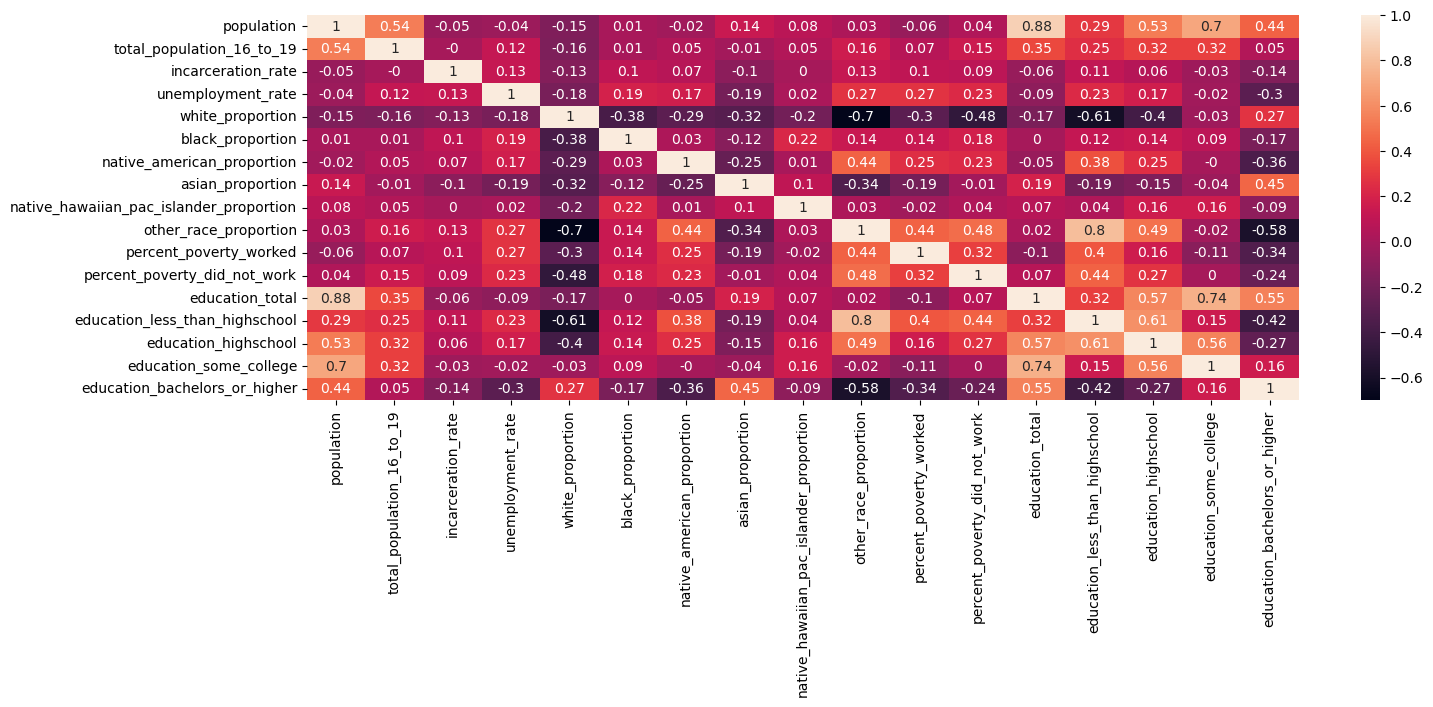

In [26]:
import seaborn as sns
correlation_matrix = predictors.corr().round(2)
plt.figure(figsize = (16,5))
sns.heatmap(data=correlation_matrix, annot=True)

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

y, X = dmatrices('incarceration_rate ~ unemployment_rate + C(Area_Type) + population + percent_poverty_worked + percent_poverty_did_not_work + C(plurality_race) + white_proportion + black_proportion + native_american_proportion + asian_proportion + native_hawaiian_pac_islander_proportion +  other_race_proportion   + education_total + education_less_than_highschool + education_highschool + education_some_college + education_bachelors_or_higher + total_population_16_to_19', data = predictors, return_type = 'dataframe')

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns

vif



Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/ianduke/anaconda3/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF Factor,features
0,6890.300633,Intercept
1,1.224777,C(Area_Type)[T.Urban]
2,680.031795,C(plurality_race)[T.Asian]
3,119.943867,C(plurality_race)[T.Black or African American]
4,1160.201383,C(plurality_race)[T.Some Other Race]
5,1443.465449,C(plurality_race)[T.White]
6,1.200779,unemployment_rate
7,6.133064,population
8,1.384041,percent_poverty_worked
9,1.466658,percent_poverty_did_not_work


## Yikes! We have perfect correlations between education columns. This makes sense. Let's remove the education_total column

In [74]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

y, X = dmatrices('incarceration_rate ~ unemployment_rate + C(Area_Type) + population + percent_poverty_worked + percent_poverty_did_not_work + C(plurality_race) + white_proportion + black_proportion + native_american_proportion + asian_proportion + native_hawaiian_pac_islander_proportion +  other_race_proportion  + education_less_than_highschool + education_highschool + education_some_college + education_bachelors_or_higher + total_population_16_to_19', data = predictors, return_type = 'dataframe')

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns

vif

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


,VIF Factor,features
0,6890.300633,Intercept
1,1.224777,C(Area_Type)[T.Urban]
2,680.031795,C(plurality_race)[T.Asian]
3,119.943867,C(plurality_race)[T.Black or African American]
4,1160.201383,C(plurality_race)[T.Some Other Race]
5,1443.465449,C(plurality_race)[T.White]
6,1.200779,unemployment_rate
7,6.133064,population
8,1.384041,percent_poverty_worked
9,1.466658,percent_poverty_did_not_work


# Now let's turn our attention to racial proportions. It's looking like we need to remove some kind of category. To make things cleaner, let's remove the catch all "other"

In [53]:
test = predictors[predictors['plurality_race'] != 'Some Other Race']


In [59]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

y, X = dmatrices('incarceration_rate ~ unemployment_rate + C(Area_Type) + population + percent_poverty_worked + percent_poverty_did_not_work + white_proportion + black_proportion + native_american_proportion + asian_proportion + native_hawaiian_pac_islander_proportion  + education_less_than_highschool + education_highschool + education_some_college + education_bachelors_or_higher + total_population_16_to_19', data = test, return_type = 'dataframe')

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns

vif

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


,VIF Factor,features
0,156.060942,Intercept
1,1.218927,C(Area_Type)[T.Urban]
2,1.171254,unemployment_rate
3,6.456845,population
4,1.141248,percent_poverty_worked
5,1.239631,percent_poverty_did_not_work
6,7.585381,white_proportion
7,2.483082,black_proportion
8,1.289658,native_american_proportion
9,5.599382,asian_proportion


# Great! At this point, let's calculate some GVIF's to look at our categorical predictors

In [87]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def compute_gvif(data, formula):
    gvifs = []
    y, X = dmatrices(formula, data=data, return_type='dataframe')
    
    for column in X.columns:
        # Removing the predictor of interest from the predictors list
        cols_without_current = [col for col in X.columns if col != column]
        
        # If the intercept is not in the list, add it
        if 'Intercept' not in cols_without_current:
            cols_without_current.insert(0, 'Intercept')
        
        # Model
        model = sm.OLS(X[column], X[cols_without_current]).fit()
        r_squared = model.rsquared
        
        # Degrees of freedom for categorical predictors is k-1, where k is number of categories.
        # For continuous predictors, df is 1.
        if 'Intercept' not in column and "[T." in column:
            original_col = column.split("[T.")[0].split("C(")[-1] # Extracts 'Area_Type' from 'C(Area_Type)[T.Urban]'
            d = len(data[original_col].unique()) - 1
        else:
            d = 1
        
        # GVIF calculation
        gvif = 1 / (1 - r_squared)
        gvif_power = gvif**(1/(2*d))
        gvifs.append(gvif_power)
    
    return pd.DataFrame({
        'Variable': X.columns,
        'GVIF^(1/(2d))': gvifs
    })

# Example usage:
formula = 'incarceration_rate ~ unemployment_rate + Area_Type + plurality_race + population + percent_poverty_worked + percent_poverty_did_not_work + education_less_than_highschool + education_highschool + education_some_college + education_bachelors_or_higher + total_population_16_to_19' 
gvif_df = compute_gvif(predictors, formula)
gvif_df


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/ianduke/anaconda3/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1781: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Variable,GVIF^(1/(2d))
0,Intercept,0.000000
1,Area_Type[T.Urban],1.040581
2,plurality_race[T.Asian],2.127033
3,plurality_race[T.Black or African American],1.712512
4,plurality_race[T.Some Other Race],2.273871
5,plurality_race[T.White],2.337269
6,unemployment_rate,1.089698
7,population,2.472815
8,percent_poverty_worked,1.157434
9,percent_poverty_did_not_work,1.175184


### Interpretation: Our GVIFs are all less than 5, which means the level of multicollinearity in the system is acceptable! This changes when we add race proportions (because the race plurality is obviously correlated with the race proportions), so we'll have to decide to go with one or the other!

In [88]:
reg = smf.ols('incarceration_rate ~ unemployment_rate + Area_Type + plurality_race + population + percent_poverty_worked + percent_poverty_did_not_work + education_less_than_highschool + education_highschool + education_some_college + education_bachelors_or_higher + total_population_16_to_19' 
, data = predictors).fit()
reg.summary() 

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     incarceration_rate   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     18.61
Date:                Wed, 04 Oct 2023   Prob (F-statistic):           1.46e-46
Time:                        11:29:36   Log-Likelihood:                -59274.
No. Observations:                7281   AIC:                         1.186e+05
Df Residuals:                    7266   BIC:                         1.187e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
===============================================================================================================
                                                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                     167.2267    588.941      0.284      0.776    -987.268    1321.722
Area_Type[T.Urban]                             47.6368     48.456      0.983      0.326     -47.351     142.624
plurality_race[T.Asian]                        -5.8017    590.446     -0.010      0.992   -1163.247    1151.644
plurality_race[T.Black or African American]   250.7495    593.759      0.422      0.673    -913.190    1414.689
plurality_race[T.Some Other Race]              90.3275    590.274      0.153      0.878   -1066.781    1247.436
plurality_race[T.White]                        23.4756    589.697      0.040      0.968   -1132.501    1179.452
unemployment_rate                              17.3944      2.671      6.513      0.000      12.159      22.630
population                                     -0.0217      0.014     -1.529      0.126      -0.050       0.006
percent_poverty_worked                          5.2589      2.922      1.799      0.072      -0.470      10.988
percent_poverty_did_not_work                    0.8921      0.474      1.881      0.060      -0.038       1.822
education_less_than_highschool                  0.0706      0.051      1.383      0.167      -0.029       0.171
education_highschool                            0.0227      0.057      0.400      0.689      -0.089       0.134
education_some_college                          0.0274      0.045      0.607      0.544      -0.061       0.116
education_bachelors_or_higher                  -0.0622      0.027     -2.336      0.020      -0.114      -0.010
total_population_16_to_19                      -0.0386      0.060     -0.639      0.523      -0.157       0.080
==============================================================================
Omnibus:                    26973.845   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      13471768609.558
Skew:                          79.862   Prob(JB):                         0.00
Kurtosis:                    6664.893   Cond. No.                     6.61e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.61e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [89]:
reg = smf.ols('incarceration_rate ~ unemployment_rate + C(Area_Type) + population + percent_poverty_worked + black_proportion + white_proportion + asian_proportion + percent_poverty_did_not_work  + education_total + education_less_than_highschool + education_highschool + education_some_college + education_bachelors_or_higher + total_population_16_to_19', data = predictors).fit()
reg.summary() 

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     incarceration_rate   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     28.46
Date:                Wed, 04 Oct 2023   Prob (F-statistic):           3.53e-69
Time:                        11:44:12   Log-Likelihood:                -59221.
No. Observations:                7281   AIC:                         1.185e+05
Df Residuals:                    7267   BIC:                         1.186e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                        868.0229     91.582      9.478      0.000     688.495    1047.551
C(Area_Type)[T.Urban]            -49.5062     49.425     -1.002      0.317    -146.393      47.381
unemployment_rate                 16.2054      2.661      6.089      0.000      10.989      21.422
population                        -0.0188      0.014     -1.337      0.181      -0.046       0.009
percent_poverty_worked             2.2180      2.915      0.761      0.447      -3.496       7.932
black_proportion                 -43.5802    143.486     -0.304      0.761    -324.854     237.694
white_proportion                -820.7197     90.447     -9.074      0.000    -998.022    -643.417
asian_proportion                -817.6429     94.899     -8.616      0.000   -1003.673    -631.613
percent_poverty_did_not_work      -0.0635      0.481     -0.132      0.895      -1.007       0.880
education_total                   -0.0292      0.020     -1.487      0.137      -0.068       0.009
education_less_than_highschool    -0.1069      0.044     -2.419      0.016      -0.193      -0.020
education_highschool              -0.0080      0.051     -0.157      0.875      -0.108       0.092
education_some_college             0.0476      0.039      1.215      0.225      -0.029       0.124
education_bachelors_or_higher      0.0381      0.020      1.924      0.054      -0.001       0.077
total_population_16_to_19         -0.0409      0.060     -0.682      0.495      -0.158       0.077
==============================================================================
Omnibus:                    26972.464   Durbin-Watson:                   1.956
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      13467036716.606
Skew:                          79.849   Prob(JB):                         0.00
Kurtosis:                    6663.722   Cond. No.                     4.54e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.07e-22. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

NameError: name 'filelist' is not defined